In [1]:
'''

1. INSTALL PACKAGE AND UPLOAD DATA

'''

'\n\n1. INSTALL PACKAGE AND UPLOAD DATA\n\n'

In [2]:
pip install p_tqdm


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install dcor


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install iisignature


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import TheilSenRegressor
from sklearn.linear_model import LinearRegression

In [5]:
# Read the CSV file
df1 = pd.read_csv('../../Data/daily_price.csv')

data = df1.set_index('ticker')

data

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/1/2021,0.04210,0.008912,0.019052,1.3587,728.91,2.6378,NaN,0.36169,0.012224,4.0817,...,0.13561,NaN,0.23746,0.02685,5.861,90.711,0.005680,14.461,0.036973,2.268
1/2/2021,0.04095,0.008557,0.019993,1.4124,774.56,2.6321,NaN,0.32751,0.011317,3.6083,...,0.13156,NaN,0.22064,0.02721,5.420,85.768,0.010526,14.426,0.038107,2.249
1/3/2021,0.04129,0.008610,0.026226,1.4707,978.28,2.7985,NaN,0.29857,0.009871,4.4294,...,0.13500,NaN,0.22540,0.02949,5.829,93.778,0.009821,16.024,0.040928,2.466
1/4/2021,0.04135,0.008397,0.024598,1.3868,1041.43,2.8191,NaN,0.30888,0.010121,4.3500,...,0.14105,NaN,0.23565,0.03095,6.044,114.271,0.009761,16.372,0.040432,2.515
1/5/2021,0.04394,0.008499,0.027964,1.4953,1099.56,2.8862,NaN,0.33823,0.010981,4.5700,...,0.14654,NaN,0.22573,0.02852,6.196,119.689,0.009970,16.868,0.041700,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,0.09229,0.030890,0.025950,5.1770,3371.44,0.5750,0.2740,0.21870,0.001415,23.0400,...,0.19980,2.151,0.46980,0.12268,6.791,94.460,0.122760,11.340,0.334000,2.566
6/27/2024,0.09734,0.031490,0.026690,5.2230,3450.44,0.5894,0.2786,0.21780,0.001451,23.2400,...,0.19620,2.182,0.47530,0.12201,6.965,93.460,0.127110,11.620,0.340700,2.607
6/28/2024,0.09674,0.030630,0.026650,4.9620,3380.15,0.5875,0.2672,0.20730,0.001418,23.0700,...,0.19100,2.134,0.47160,0.12321,6.729,93.640,0.123060,11.400,0.336100,2.571


In [6]:
'''

2. DATA_PREPARATION

'''

'\n\n2. DATA_PREPARATION\n\n'

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
import pickle

In [8]:
# row t: gives the log return going from the close at day t - 1 to close at day t
daily_ret = np.log(data).ffill().diff().shift(-1).fillna(0)
daily_ret = daily_ret[:-1]

In [9]:
close_price = data.shift(-1).fillna(0)
close_price = close_price[:-1]

In [10]:
daily_ret = np.log(data).ffill().diff().fillna(0)
daily_ret = daily_ret[1:]

In [11]:
close_price = data[1:]

In [12]:
daily_ret

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/2/2021,-0.027696,-0.040649,0.048210,0.038762,0.060745,-0.002163,0.000000,-0.099269,-0.077095,-0.123277,...,-0.030320,0.000000,-0.073467,0.013319,-0.078224,-0.056033,0.616935,-0.002423,0.030210,-0.008413
1/3/2021,0.008269,0.006175,0.271369,0.040448,0.233501,0.061302,0.000000,-0.092514,-0.136705,0.205027,...,0.025812,0.000000,0.021344,0.080467,0.072750,0.089284,-0.069374,0.105055,0.071416,0.092112
1/4/2021,0.001452,-0.025050,-0.064086,-0.058740,0.062554,0.007334,0.000000,0.033948,0.025011,-0.018088,...,0.043840,0.000000,0.044471,0.048322,0.036221,0.197643,-0.006087,0.021485,-0.012193,0.019675
1/5/2021,0.060753,0.012074,0.128253,0.075328,0.054315,0.023523,0.000000,0.090773,0.081554,0.049337,...,0.038184,0.000000,-0.043008,-0.081767,0.024838,0.046324,0.021155,0.029846,0.030880,0.037843
1/6/2021,0.076430,0.073915,0.097213,0.030299,0.094404,0.155298,0.000000,0.089534,-0.060727,0.004062,...,0.088188,0.000000,0.096264,0.065809,0.075513,-0.038305,0.044146,0.146789,0.068465,0.142820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,-0.005834,-0.032487,-0.017950,-0.046792,-0.006937,-0.002779,-0.007273,-0.007743,-0.022363,-0.016785,...,-0.021293,-0.010176,-0.012480,0.006460,-0.021704,0.025410,-0.027240,-0.013141,-0.010721,-0.004666
6/27/2024,0.053274,0.019238,0.028117,0.008846,0.023162,0.024735,0.016649,-0.004124,0.025123,0.008643,...,-0.018182,0.014309,0.011639,-0.005476,0.025299,-0.010643,0.034822,0.024391,0.019861,0.015852
6/28/2024,-0.006183,-0.027690,-0.001500,-0.051263,-0.020582,-0.003229,-0.041780,-0.049410,-0.023006,-0.007342,...,-0.026861,-0.022244,-0.007815,0.009787,-0.034471,0.001924,-0.032381,-0.019114,-0.013594,-0.013905


In [13]:
import scipy.stats as stats

# winsorization function for a single stock
def winsorize_stock(stock_returns, lower_percentile, upper_percentile):
    return stats.mstats.winsorize(stock_returns, limits=[lower_percentile, 1-upper_percentile])

# Apply the function to each column (stock)
daily_ret = daily_ret.apply(winsorize_stock, lower_percentile=0.025, upper_percentile=0.975)

In [14]:
daily_ret.describe()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
count,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,...,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000
mean,0.000810,0.000477,0.000485,0.000868,0.001444,-0.001100,-0.002834,-0.000654,-0.001050,0.001740,...,0.000110,-0.001629,-0.000389,0.001082,0.000364,0.000227,0.001180,-0.000099,0.000385,0.000026
std,0.057853,0.051228,0.049198,0.059338,0.036760,0.044803,0.055807,0.056779,0.053173,0.061438,...,0.054552,0.043477,0.039897,0.033567,0.051310,0.051551,0.052678,0.046783,0.056759,0.049709
min,-0.126276,-0.115381,-0.112083,-0.132678,-0.087733,-0.118940,-0.143364,-0.128403,-0.124426,-0.135480,...,-0.122273,-0.112093,-0.098959,-0.093753,-0.113157,-0.118320,-0.110154,-0.111055,-0.134184,-0.115339
25%,-0.032884,-0.029607,-0.027533,-0.032568,-0.017723,-0.023444,-0.031005,-0.034420,-0.030304,-0.034315,...,-0.031973,-0.022240,-0.020526,-0.013947,-0.028267,-0.029532,-0.027122,-0.026015,-0.030927,-0.026266
50%,-0.000098,0.001587,0.000652,-0.000798,0.000927,0.000000,0.000000,-0.001516,0.000000,-0.000835,...,0.001472,0.000000,0.000060,0.002333,0.000371,0.000020,-0.000645,0.002216,-0.000272,0.002242
75%,0.031302,0.027897,0.027477,0.033793,0.021865,0.023824,0.028573,0.030803,0.027496,0.034874,...,0.029604,0.020097,0.020227,0.015931,0.027073,0.028842,0.021321,0.027133,0.029209,0.026291
max,0.150636,0.125301,0.125841,0.144168,0.087468,0.105065,0.126132,0.140632,0.126721,0.154830,...,0.138115,0.106142,0.102540,0.094108,0.131534,0.122575,0.171577,0.105118,0.151228,0.129443


In [15]:
def standardize_returns(returns):
    """
    Standardizes asset returns such that their mean is zero and standard deviation is one.

    Parameters:
    returns (pd.DataFrame): DataFrame with asset returns where rows are time periods and columns are assets.

    Returns:
    pd.DataFrame: Standardized returns with mean 0 and standard deviation 1.
    """
    # Compute mean and standard deviation for each asset
    mean_returns = returns.mean()
    std_returns = returns.std()

    # Standardize returns
    standardized_returns = (returns - mean_returns) / std_returns

    return standardized_returns

In [16]:
daily_ret = standardize_returns(daily_ret)

In [17]:
daily_ret.to_csv('./data/binance_real_data/daily_returns.csv')
daily_ret.to_pickle('./data/binance_real_data/daily_returns.pkl')

In [18]:
daily_ret = daily_ret.rename_axis("date")

In [20]:
"""

3. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING

"""

'\n\n3. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING\n\n'

In [19]:
import pickle
import itertools
import time
import networkx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from tqdm import tqdm
from p_tqdm import p_map
from importlib import reload
from models.lead_lag_measure import get_lead_lag_matrix
from models.herm_matrix_algo import get_ordered_clustering
import real_data.utils
from real_data.utils import get_ordered_matrix, compute_jaccard, compute_flow_graph, plot_flow_heatmap, \
    plot_flow_network, compute_largest_e_values_mean, permutation_mc_lead_lag, compute_test_statistic, \
    permute_feature_cluster

2.0  seconds


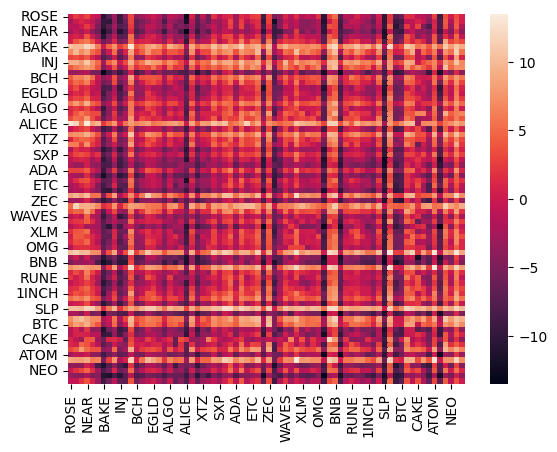

In [23]:
restricted = False
log_ret_type = '' # '_residuals'
correlation_method = 'mutual_information' # 'pearson', 'distance', 'mutual_information'
method = 'signature' # 'ccf_auc', 'ccf_at_max_lag', 'signature'

start = time.time()

if restricted:
    daily_ret = daily_ret.loc[:'2022']

lead_lag_matrix = get_lead_lag_matrix(daily_ret, method=method, max_lag=7, correlation_method=correlation_method)
end = time.time()
print(np.round(end - start), ' seconds')
sns.heatmap(lead_lag_matrix); plt.show()

if restricted:
    file_name = './data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '_restricted' + '.pkl'
else:
    file_name = './data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl'

lead_lag_matrix.to_pickle(file_name)

In [24]:
lead_lag_matrix.head()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ROSE,0.000000,2.464938,1.290738,2.974782,0.086154,-0.727427,-10.524824,-6.982994,-2.894564,-9.282325,...,1.303454,-0.886282,-1.130392,-3.038879,2.791315,-8.697729,3.637630,0.265526,3.321850,0.685972
ANKR,-2.464938,0.000000,1.220419,0.383934,-0.744536,-3.669524,-9.726779,-9.969212,-3.675873,-9.359515,...,-0.792579,0.787911,-0.523887,-4.408428,0.729449,-8.167129,4.054892,-1.839768,3.867770,0.557472
VET,-1.290738,-1.220419,0.000000,2.362465,0.093014,-5.131649,-9.914003,-6.997309,-2.616344,-7.713858,...,-0.855720,2.970638,-4.667108,-8.075467,1.136683,-8.096901,3.788144,-3.054625,4.294431,-1.623950
NEAR,-2.974782,-0.383934,-2.362465,0.000000,-3.805171,-5.953928,-12.076650,-8.765348,-4.090459,-11.001080,...,-0.590969,-3.766009,-3.761557,-5.084918,-0.051133,-8.997708,-0.469608,-4.685772,1.899576,-3.733908
ETH,-0.086154,0.744536,-0.093014,3.805171,0.000000,-3.511890,-10.662514,-5.225266,-0.843050,-7.609975,...,1.296770,-4.035111,-1.252210,-3.713444,3.885790,-6.044295,1.857726,-1.573184,5.036083,-0.667581


In [152]:
lead_lag_matrix

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ROSE,0.000000,-4.690299,-4.106797,-5.858524,-3.623846,-5.143232,9.323693,-6.154253,-4.997187,-3.040377,...,-5.737890,-1.077677,-1.772717,-3.154932,-4.931378,-8.135836,-4.575075,-4.478199,-5.004235,-4.123011
ANKR,4.690299,0.000000,-0.077600,-1.172685,-0.156135,-1.197690,8.045094,-1.538435,-0.660137,3.344570,...,-2.230966,1.882099,-1.226185,-3.093214,-0.346412,-7.526376,-0.462654,-0.335534,0.661333,-0.188679
VET,4.106797,0.077600,0.000000,-0.894778,0.330140,-1.250953,7.222182,-1.463307,-0.683911,3.122162,...,-1.914081,1.968422,-0.593867,-4.140212,-0.148158,-7.560120,-0.386416,-0.443082,0.441027,-0.218930
NEAR,5.858524,1.172685,0.894778,0.000000,0.234457,-0.130031,7.361483,-0.397840,0.276760,5.340815,...,-1.060027,2.821272,-1.265150,-2.436482,0.887488,-6.123015,0.525123,0.766578,1.780524,0.817521
ETH,3.623846,0.156135,-0.330140,-0.234457,0.000000,-1.585890,3.416286,-1.213701,-0.887267,2.982667,...,-1.930457,1.526662,-0.537439,-2.141646,0.485004,-7.509346,-0.932867,-0.778448,0.513809,-0.835320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AAVE,8.135836,7.526376,7.560120,6.123015,7.509346,5.942206,6.285295,6.121075,6.130099,8.429437,...,5.080784,8.036492,5.122125,-6.847362,6.849143,0.000000,6.958627,6.919347,7.360779,6.691179
DOGE,4.575075,0.462654,0.386416,-0.525123,0.932867,-0.797475,7.453627,-0.953613,-0.024125,2.888383,...,-1.557126,2.864608,0.152304,-4.415727,0.503370,-6.958627,0.000000,0.028429,1.032926,0.283333
NEO,4.478199,0.335534,0.443082,-0.766578,0.778448,-0.873039,8.067401,-1.218669,-0.205342,2.971418,...,-1.678456,3.091533,0.057647,-4.338703,0.235729,-6.919347,-0.028429,0.000000,0.795686,0.250184
SAND,5.004235,-0.661333,-0.441027,-1.780524,-0.513809,-1.643500,8.170804,-2.312166,-1.118921,3.022290,...,-2.649145,2.100812,-1.117609,-2.898082,-0.825864,-7.360779,-1.032926,-0.795686,0.000000,-0.552600


In [25]:
# computing average vol
volatility = daily_ret.std()

# computing hermitian rw clustering
hermitian_clustering = get_ordered_clustering(lead_lag_matrix, num_clusters=6)

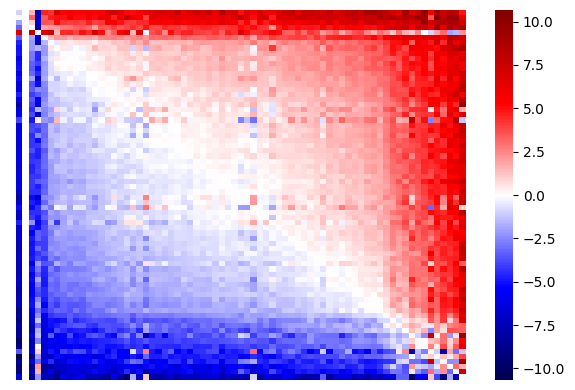

In [154]:
ordering_method = ['row_sums', 'herm_rw_clustering'][0] # Choose 'row_sums' in this study
_ = get_ordered_matrix(lead_lag_matrix, method=ordering_method, num_clusters=6)
_ = pd.DataFrame(_)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(_, cmap='seismic', xticklabels=False, yticklabels=False, ax=ax)
plt.tight_layout()
plt.show()

In [27]:
'''

SIGNIFICANCE TEST (MONTE CARLO SIMULATION)

'''

'\n\nSIGNIFICANCE TEST (MONTE CARLO SIMULATION)\n\n'

In [28]:
# checking if SLURM multiprocessing
try:
    ncpu = os.environ["SLURM_JOB_CPUS_PER_NODE"]
    ncpu = sum(int(num) for num in ncpu.split(','))
    print('number of SLURM CPUS: ', ncpu)
except KeyError:
    ncpu = 1

In [29]:
n_samples = 1000
seeds = range(n_samples)

In [30]:
correlation_method = 'mutual_information'
method = 'signature'
max_lag = 7

permutation_mc_lead_lag = partial(permutation_mc_lead_lag, log_ret=daily_ret,max_lag=max_lag, method=method, correlation_method=correlation_method)
lead_lag_perm_results = p_map(permutation_mc_lead_lag, seeds, num_cpus=ncpu)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [85]:
import os
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import pickle

# ✅ 设置参数
correlation_method = 'mutual_information'  # 可以换成 'distance' 或 'pearson' 来提速
method = 'ccf_auc'
max_lag = 7
ncpu = 7  # 改成你机器的核数
outdir = "perm_results"  # 缓存结果文件夹

# ✅ 你需要预定义这些变量：
# daily_ret: DataFrame, shape (T, N)
# seeds: List[int]，随机种子列表
# get_lead_lag_matrix: 你已有的函数

# ✅ 主计算函数
def clean_permutation(seed, log_ret, max_lag, method, correlation_method):
    np.random.seed(seed)
    log_ret_values = log_ret.values.copy()
    row_permutation = np.random.permutation(log_ret.shape[0])
    log_ret_perm = log_ret_values[row_permutation, :]
    log_ret_perm = pd.DataFrame(log_ret_perm, index=log_ret.index, columns=log_ret.columns)

    return get_lead_lag_matrix(
        log_ret_perm,
        method=method,
        max_lag=max_lag,
        correlation_method=correlation_method
    )

# ✅ 包装：支持缓存中间结果
def cached_clean_permutation(seed, log_ret, max_lag, method, correlation_method, outdir="perm_results"):
    os.makedirs(outdir, exist_ok=True)
    cache_file = os.path.join(outdir, f"seed_{seed}.pkl")
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    result = clean_permutation(seed, log_ret, max_lag, method, correlation_method)
    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)
    return result

# ✅ 并行执行
lead_lag_perm_results = Parallel(n_jobs=ncpu)(
    delayed(cached_clean_permutation)(
        seed, daily_ret, max_lag, method, correlation_method, outdir
    )
    for seed in tqdm(seeds, desc="Running permutations")
)


# ✅ （可选）合并结果后保存
# result_array = np.stack(lead_lag_perm_results)
# pd.to_pickle(result_array, "all_perm_results.pkl")


Running permutations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:23<00:00, 43.16it/s]


In [31]:
log_ret_type = ''
correlation_method = 'mutual_information'
method = 'signature'
max_lag = 7

with open('./data/binance_pickled_data/permutation_mc_lead_lag_'+ correlation_method +'_' + method +'.pkl', 'wb') as f:
    pickle.dump(permutation_mc_lead_lag, f)
with open('./data/binance_pickled_data/lead_lag_perm_'+correlation_method+'_'+method+'_results.pkl', 'wb') as f:
    pickle.dump(lead_lag_perm_results, f)
lead_lag_matrix = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [32]:
log_ret_type = ''
correlation_method = 'mutual_information'
method = 'signature'
max_lag = 7

lead_lag_perm_results = pd.read_pickle('./data/binance_pickled_data/lead_lag_perm_mutual_information_ccf_auc_results.pkl')

permutation_mc_lead_lag = pd.read_pickle('./data/binance_pickled_data/permutation_mc_lead_lag_mutual_information_ccf_auc.pkl')

0.000999000999000999


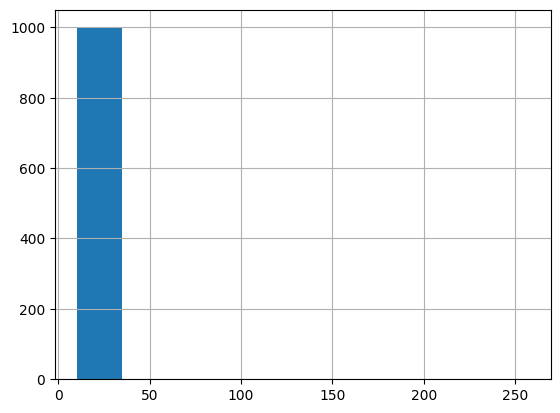

In [33]:
# compute e_val_results from lead_lag_matrix_list
top_n = 1
e_val_results = [compute_largest_e_values_mean(lead_lag_mat, top_n) for lead_lag_mat in lead_lag_perm_results]
# p-value is computed under the null hypothesis so the real data is added to e_val_results
real_e_val_mean = compute_largest_e_values_mean(lead_lag_matrix.values, top_n)
e_val_results.append(real_e_val_mean)
e_val_results = pd.Series(e_val_results)
print((e_val_results >= real_e_val_mean).mean())
e_val_results.hist(); plt.show()

In [34]:
real_e_val_mean

257.13522388010415

In [41]:
"""

4. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING ACROSS TIME SCALE

"""

'\n\n4. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING ACROSS TIME SCALE\n\n'

In [35]:
log_ret_type = '' # '_residuals'
correlation_method = 'mutual_information'
method = 'signature'

lead_lag_matrix = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [22]:
from importlib import reload
import itertools
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from models.lead_lag_measure import get_lead_lag_matrix
from models.herm_matrix_algo import get_ordered_clustering
import real_data.utils
from real_data.utils import get_ordered_matrix, compute_jaccard, compute_flow_graph, plot_flow_heatmap, \
    plot_flow_network
import real_data.rolling_utils
from real_data.rolling_utils import get_rolling_lead_lag_matrix, get_cluster_rolling_metric, get_flow_graph_rolling

In [23]:
log_ret_type = ''  # _residuals
lookback = 30 # 1 month lookback period
update_freq = 1 # (1, 7, 14, 30)
correlation_method = 'pearson'  # ''
method = 'signature'

daily_ret.index = pd.to_datetime(daily_ret.index)

lead_lag_matrix_rolling = get_rolling_lead_lag_matrix(daily_ret, lookback=lookback,
                                                      update_freq=update_freq,
                                                      method=method, max_lag=7, correlation_method=correlation_method)
lead_lag_matrix_rolling.to_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                  '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')


  0%|          | 0/534 [00:00<?, ?it/s]

In [24]:
log_ret_type = ''  # _residuals
lookback = 30
update_freq = 1
correlation_method = 'pearson'
method = 'signature'

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
AxesSubplot(0.125,0.2;0.775x0.68)
Annual Return (%)    28.650458
Sharpe Ratio          0.799057
Volatility (%)       43.055864
Max Drawdown (%)    -66.147682
dtype: float64


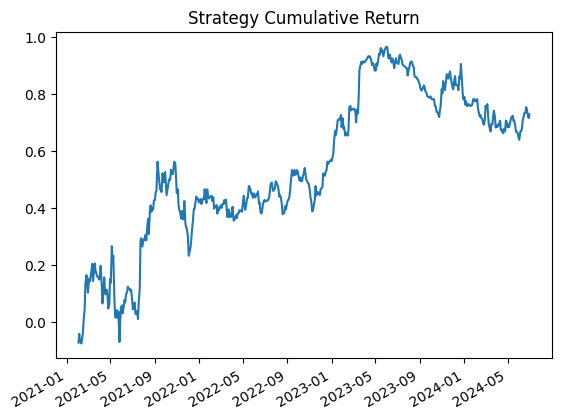

In [26]:
def backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling, quantile=0.1):
    log_returns = np.log(prices).diff()
    log_returns.index = pd.to_datetime(log_returns.index)
    log_returns = log_returns.sort_index() 
    print("Log return index sorted?:", log_returns.index.is_monotonic_increasing)
    print("Log return index unique?:", log_returns.index.is_unique)

    daily_returns = []
    backtest_dates = []
    print("Lead-lag matrix index sorted?:", lead_lag_matrix_rolling.index.is_monotonic_increasing)
    

    for date in lead_lag_matrix_rolling.index:
        date = pd.Timestamp(date)
        matrix = lead_lag_matrix_rolling.loc[date]

        if matrix.isnull().all().all():
            continue

        lead_scores = matrix.mean(axis=1)
        top_thresh = lead_scores.quantile(1 - quantile)
        bottom_thresh = lead_scores.quantile(quantile)

        #leaders = lead_scores[lead_scores >= top_thresh].index
        #followers = lead_scores[lead_scores <= bottom_thresh].index

        followers = lead_scores[lead_scores >= top_thresh].index
        leaders = lead_scores[lead_scores <= bottom_thresh].index

        if len(leaders) == 0 or len(followers) == 0:
            continue

        # Use indexer to find next available date
        try:
            idx = log_returns.index.get_indexer([date], method='pad')[0]
            next_day = log_returns.index[idx + 1]
        except (IndexError, KeyError):
            continue

        r = log_returns.loc[next_day]

        long_leg = r[leaders].dropna().mean()
        short_leg = r[followers].dropna().mean()
        daily_ret = long_leg - short_leg

        daily_returns.append(daily_ret)
        backtest_dates.append(next_day)

    returns = pd.Series(daily_returns, index=backtest_dates, name="strategy_return")
    
    return returns


def evaluate_strategy(returns, risk_free_rate=0):
    ann_factor = 252
    excess_ret = returns - risk_free_rate / ann_factor

    sharpe = excess_ret.mean() / excess_ret.std() * np.sqrt(ann_factor)
    volatility = returns.std() * np.sqrt(ann_factor)
    cumulative_return = (1 + returns).cumprod() - 1
    max_drawdown = (cumulative_return - cumulative_return.cummax()).min()
    annual_return = (1 + cumulative_return[-1]) ** (ann_factor / len(returns)) - 1

    stats = {
        'Annual Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe,
        'Volatility (%)': volatility * 100,
        'Max Drawdown (%)': max_drawdown * 100,
    }
    return stats

prices = data
returns = backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling)
stats = evaluate_strategy(returns)

print(returns.cumsum().plot(title="Strategy Cumulative Return"))
print(pd.Series(stats))


In [27]:
import matplotlib.pyplot as plt
import os
from datetime import datetime

def save_backtest_result(returns, stats, label="strategy1", output_dir="./results"):
    """
    保存策略图、收益数据、统计指标
    :param returns: pd.Series 策略每日收益
    :param stats: dict 策略指标
    :param label: 文件名标记（比如方法名+参数）
    :param output_dir: 存储目录
    """
    os.makedirs(output_dir, exist_ok=True)

    now_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    prefix = f"{output_dir}/{label}_{now_str}"

    # 1️⃣ 保存累计收益图
    plt.figure(figsize=(10, 6))
    returns.cumsum().plot()
    plt.title(f"Cumulative Return - {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{prefix}_cum_return.png")
    plt.close()

    # 2️⃣ 保存每日收益数据
    returns.to_csv(f"{prefix}_returns.csv")

    # 3️⃣ 保存策略统计指标
    pd.Series(stats).to_csv(f"{prefix}_stats.csv")

    print(f"✅ Saved to: {prefix}_*.png/.csv")

# === 主流程 ===
prices = data
returns = backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling, quantile=0.1)
stats = evaluate_strategy(returns)

save_backtest_result(returns, stats, label="signature_lead_0.1")  # ← 你可以自定义策略名


Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
✅ Saved to: ./results/signature_lead_0.1_20250804_211403_*.png/.csv


Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
[2021-02-02] Long (Leaders): 0.00777, Short (Followers): 0.03180, Return: -0.02403
[2021-02-04] Long (Leaders): 0.00126, Short (Followers): -0.01237, Return: 0.01363
[2021-02-06] Long (Leaders): -0.00917, Short (Followers): -0.04376, Return: 0.03458
[2021-02-10] Long (Leaders): 0.03793, Short (Followers): -0.00377, Return: 0.04170
[2021-02-12] Long (Leaders): 0.07004, Short (Followers): 0.03718, Return: 0.03287
[2021-02-14] Long (Leaders): -0.06496, Short (Followers): -0.05959, Return: -0.00538
[2021-02-17] Long (Leaders): 0.06202, Short (Followers): 0.01822, Return: 0.04379
[2021-02-19] Long (Leaders): 0.05253, Short (Followers): 0.00055, Return: 0.05198
[2021-02-21] Long (Leaders): 0.09713, Short (Followers): 0.05753, Return: 0.03960
[2021-02-24] Long (Leaders): 0.08975, Short (Followers): 0.04383, Return: 0.04591
[2021-02-26] Long (Leaders): -0.01696, Short (Followers): 0.00060, Return:

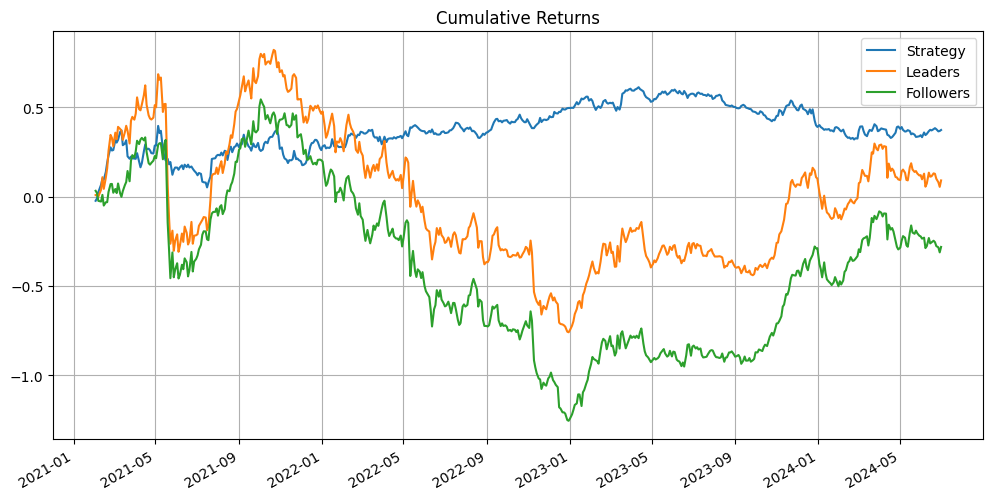

Annual Return (%)    13.160009
Sharpe Ratio          0.544745
Volatility (%)       32.207564
Max Drawdown (%)    -44.108355
dtype: float64


In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling, quantile=0.2):
    log_returns = np.log(prices).diff()
    log_returns.index = pd.to_datetime(log_returns.index)
    log_returns = log_returns.sort_index()
    
    print("Log return index sorted?:", log_returns.index.is_monotonic_increasing)
    print("Log return index unique?:", log_returns.index.is_unique)

    # Ensure rolling matrix index matches returns index
    aligned_dates = lead_lag_matrix_rolling.index.intersection(log_returns.index)
    lead_lag_matrix_rolling = lead_lag_matrix_rolling.loc[aligned_dates]

    daily_returns = []
    backtest_dates = []
    leader_returns = []
    follower_returns = []

    print("Lead-lag matrix index sorted?:", lead_lag_matrix_rolling.index.is_monotonic_increasing)

    for date in lead_lag_matrix_rolling.index:
        date = pd.Timestamp(date)
        matrix = lead_lag_matrix_rolling.loc[date]

        if matrix.isnull().all().all():
            continue

        lead_scores = matrix.mean(axis=1)
        top_thresh = lead_scores.quantile(1 - quantile)
        bottom_thresh = lead_scores.quantile(quantile)

        followers = lead_scores[lead_scores >= top_thresh].index
        leaders = lead_scores[lead_scores <= bottom_thresh].index

        if len(leaders) == 0 or len(followers) == 0:
            continue

        # 获取当前日期之后的一个交易日
        try:
            idx = log_returns.index.get_loc(date)
            next_day = log_returns.index[idx + 1]
        except (IndexError, KeyError):
            continue

        # 获取下一个交易日的 log return
        r = log_returns.loc[next_day]

        long_leg = r[leaders].dropna().mean()
        short_leg = r[followers].dropna().mean()
        daily_ret = long_leg - short_leg

        # 存储结果
        daily_returns.append(daily_ret)
        backtest_dates.append(next_day)
        leader_returns.append(long_leg)
        follower_returns.append(short_leg)

        print(f"[{next_day.date()}] Long (Leaders): {long_leg:.5f}, Short (Followers): {short_leg:.5f}, Return: {daily_ret:.5f}")

    returns = pd.Series(daily_returns, index=backtest_dates, name="strategy_return")
    leaders_series = pd.Series(leader_returns, index=backtest_dates, name="leaders_return")
    followers_series = pd.Series(follower_returns, index=backtest_dates, name="followers_return")

    return returns, leaders_series, followers_series


def evaluate_strategy(returns, risk_free_rate=0):
    ann_factor = 252
    excess_ret = returns - risk_free_rate / ann_factor

    sharpe = excess_ret.mean() / excess_ret.std() * np.sqrt(ann_factor)
    volatility = returns.std() * np.sqrt(ann_factor)
    cumulative_return = (1 + returns).cumprod() - 1
    max_drawdown = (cumulative_return - cumulative_return.cummax()).min()
    annual_return = (1 + cumulative_return[-1]) ** (ann_factor / len(returns)) - 1

    stats = {
        'Annual Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe,
        'Volatility (%)': volatility * 100,
        'Max Drawdown (%)': max_drawdown * 100,
    }
    return stats



returns, leaders, followers = backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling)
stats = evaluate_strategy(returns)


plt.figure(figsize=(12, 6))
returns.cumsum().plot(label="Strategy")
leaders.cumsum().plot(label="Leaders")
followers.cumsum().plot(label="Followers")
plt.legend()
plt.title("Cumulative Returns")
plt.grid(True)
plt.show()

print(pd.Series(stats))


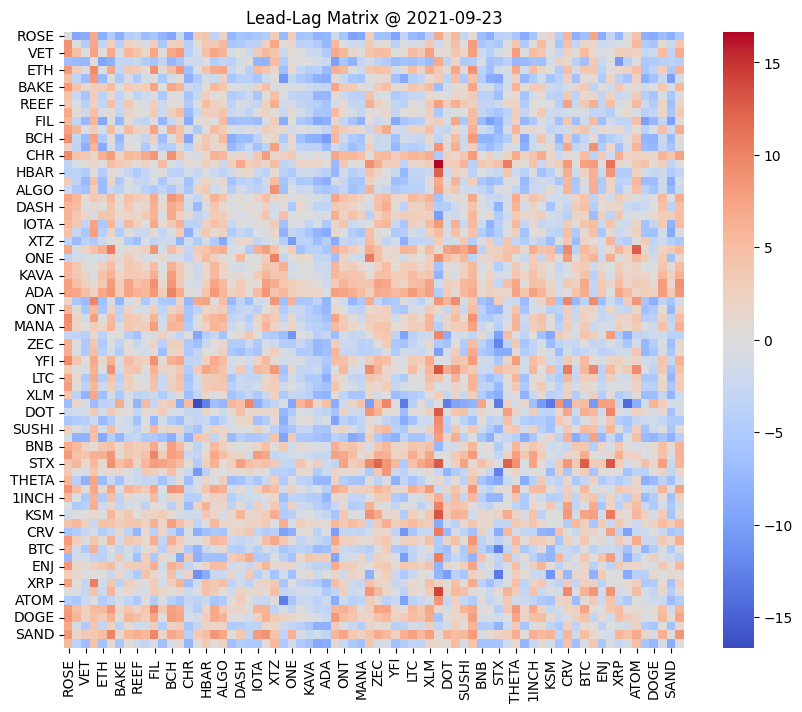

平均非对称性（|A - A^T|）：7.1422


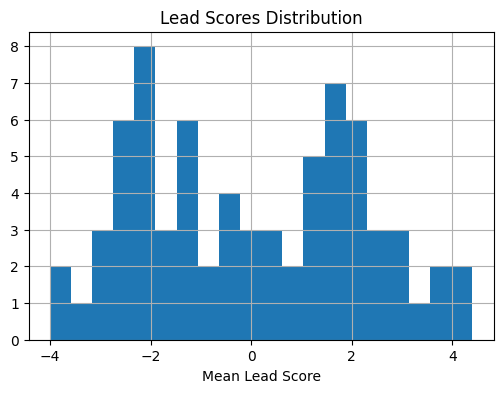

10天内最常被识别为 leader 的资产：
RUNE     8
CRV      8
UNI      8
SUSHI    8
AAVE     7
1INCH    7
AVAX     7
FTM      6
SNX      6
CAKE     5
dtype: int64


In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# 选择某个时间点检查
sample_date = lead_lag_matrix_rolling.index[100]  # 可以换成你关心的日期
matrix = lead_lag_matrix_rolling.loc[sample_date]

# --- 1. 可视化 lead-lag 矩阵 ---
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, cmap="coolwarm", center=0, annot=False)
plt.title(f"Lead-Lag Matrix @ {sample_date.date()}")
plt.show()

# --- 2. 统计对称性 ---
asymmetry = (matrix - matrix.T).abs()
asymmetry_mean = asymmetry.values[np.triu_indices_from(asymmetry, k=1)].mean()
print(f"平均非对称性（|A - A^T|）：{asymmetry_mean:.4f}")

# --- 3. 每只资产的平均lead值（得分分布） ---
lead_scores = matrix.mean(axis=1)

plt.figure(figsize=(6, 4))
lead_scores.hist(bins=20)
plt.title("Lead Scores Distribution")
plt.xlabel("Mean Lead Score")
plt.grid(True)
plt.show()

# --- 4. 哪些资产经常是leaders ---
# 统计前10个日期中被归为leaders次数
quantile = 0.2
leader_counter = {}

for date in lead_lag_matrix_rolling.index[:10]:  # 可扩展到更多
    m = lead_lag_matrix_rolling.loc[date]
    s = m.mean(axis=1)
    top_thresh = s.quantile(1 - quantile)
    leaders = s[s >= top_thresh].index
    for asset in leaders:
        leader_counter[asset] = leader_counter.get(asset, 0) + 1

# 排序输出
leader_df = pd.Series(leader_counter).sort_values(ascending=False)
print("10天内最常被识别为 leader 的资产：")
print(leader_df.head(10))


In [168]:
prices

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/1/2021,0.04210,0.008912,0.019052,1.3587,728.91,2.6378,NaN,0.36169,0.012224,4.0817,...,0.13561,NaN,0.23746,0.02685,5.861,90.711,0.005680,14.461,0.036973,2.268
1/2/2021,0.04095,0.008557,0.019993,1.4124,774.56,2.6321,NaN,0.32751,0.011317,3.6083,...,0.13156,NaN,0.22064,0.02721,5.420,85.768,0.010526,14.426,0.038107,2.249
1/3/2021,0.04129,0.008610,0.026226,1.4707,978.28,2.7985,NaN,0.29857,0.009871,4.4294,...,0.13500,NaN,0.22540,0.02949,5.829,93.778,0.009821,16.024,0.040928,2.466
1/4/2021,0.04135,0.008397,0.024598,1.3868,1041.43,2.8191,NaN,0.30888,0.010121,4.3500,...,0.14105,NaN,0.23565,0.03095,6.044,114.271,0.009761,16.372,0.040432,2.515
1/5/2021,0.04394,0.008499,0.027964,1.4953,1099.56,2.8862,NaN,0.33823,0.010981,4.5700,...,0.14654,NaN,0.22573,0.02852,6.196,119.689,0.009970,16.868,0.041700,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,0.09229,0.030890,0.025950,5.1770,3371.44,0.5750,0.2740,0.21870,0.001415,23.0400,...,0.19980,2.151,0.46980,0.12268,6.791,94.460,0.122760,11.340,0.334000,2.566
6/27/2024,0.09734,0.031490,0.026690,5.2230,3450.44,0.5894,0.2786,0.21780,0.001451,23.2400,...,0.19620,2.182,0.47530,0.12201,6.965,93.460,0.127110,11.620,0.340700,2.607
6/28/2024,0.09674,0.030630,0.026650,4.9620,3380.15,0.5875,0.2672,0.20730,0.001418,23.0700,...,0.19100,2.134,0.47160,0.12321,6.729,93.640,0.123060,11.400,0.336100,2.571


In [39]:
log_ret_type = ''  # _residuals
lookback = 30
update_freq = 1
correlation_method = 'mutual_information'
method = 'signature'

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [173]:
'''GENERATE CLUSTERS_ROLLING AND FLOW_GRAPH_ROLLING'''
log_ret_type = ''  # _residuals
lookback = 30
update_freq = 1
correlation_method = 'mutual_information'
method = 'signature'
daily_ret.index = pd.to_datetime(daily_ret.index)

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

clusters_rolling = lead_lag_matrix_rolling.apply(get_ordered_clustering, num_clusters=6)

clusters_rolling.to_pickle('./data/binance_pickled_data/clusters_rolling_lookback_' + str(lookback) + '_update_freq_' +
                           str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')
flow_graph_rolling = get_flow_graph_rolling(lead_lag_matrix_rolling, clusters_rolling, normalise=True)
flow_graph_rolling.to_pickle('./data/binance_pickled_data/flow_graph_rolling_lookback_' + str(lookback) + '_update_freq_' +
                             str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [174]:
clusters_rolling.head()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
2021-02-01,3,3,3,3,3,5,4,5,3,4,...,3,4,2,2,5,4,5,1,3,1
2021-02-03,3,5,3,0,3,4,1,1,5,0,...,3,1,4,4,0,1,5,2,3,2
2021-02-05,2,5,2,2,2,3,1,1,2,1,...,2,1,5,3,1,1,3,4,2,4
2021-02-09,0,4,4,0,1,3,1,1,0,1,...,2,2,3,4,2,2,2,4,2,4
2021-02-11,1,2,3,1,2,4,2,1,1,1,...,3,0,4,4,0,0,0,3,0,4


In [185]:
analysis = []

for date in lead_lag_matrix_rolling.index:
    if date not in clusters_rolling.index:
        continue

    lead_lag = lead_lag_matrix_rolling.loc[date]
    clusters = clusters_rolling.loc[date]

    if lead_lag.isnull().all().all():
        continue

    # Step 1: 每个资产的 lead_score
    lead_scores = lead_lag.mean(axis=1)

    # Step 2: quantile 挑出 top leaders
    top_thresh = lead_scores.quantile(1 - quantile)
    top_leaders = lead_scores[lead_scores >= top_thresh].index

    # Step 3: 构造 cluster 映射
    clusters = clusters.astype("Int64")
    asset_cluster = pd.Series(clusters.to_dict())

    # Step 4: 按 cluster 排名 → 生成映射：原 cluster ID → rank（0 是最强）
    cluster_lead_scores = lead_scores.groupby(asset_cluster).mean().sort_values(ascending=False)
    cluster_id_map = {orig_id: new_rank for new_rank, orig_id in enumerate(cluster_lead_scores.index)}
    normalized_cluster = asset_cluster.map(cluster_id_map)  # 每个资产的新 cluster ID（按得分排序）

    # Step 5: 提取最强的 cluster（编号0）
    top_cluster_assets = normalized_cluster[normalized_cluster == 0].index

    # Step 6: 计算重合
    overlap = set(top_leaders).intersection(set(top_cluster_assets))
    overlap_ratio = len(overlap) / len(top_leaders)

    analysis.append({
        "date": date,
        "overlap_with_top_leaders": len(overlap),
        "overlap_ratio": overlap_ratio,
        "top_leader_count": len(top_leaders),
        "top_cluster_size": len(top_cluster_assets),
    })

df_analysis = pd.DataFrame(analysis).set_index("date")


<AxesSubplot:title={'center':'Overlap between top quantile leaders and top cluster'}, xlabel='date'>

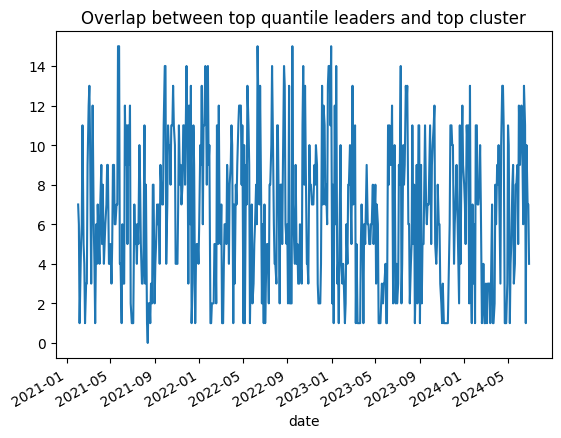

In [187]:
df_analysis['overlap_with_top_leaders'].plot(title="Overlap between top quantile leaders and top cluster")


Annual Return (%)    36.554881
Sharpe Ratio          1.309919
Volatility (%)       26.469639
Max Drawdown (%)    -55.849572
dtype: float64


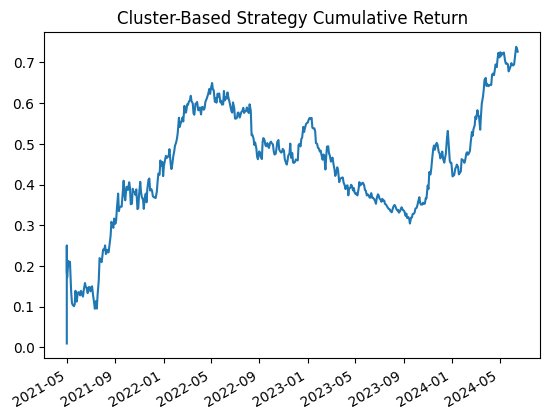

In [190]:
def cluster_based_backtest(prices, lead_lag_matrix_rolling, clusters_rolling, quantile=0.2):
    log_returns = np.log(prices).diff().dropna()
    log_returns.index = pd.to_datetime(log_returns.index)

    daily_returns = []
    backtest_dates = []

    for date in lead_lag_matrix_rolling.index:
        if date not in clusters_rolling.index:
            continue

        lead_lag = lead_lag_matrix_rolling.loc[date]
        clusters = clusters_rolling.loc[date]

        cluster_returns = []

        for cluster_id in clusters.unique():
            assets = clusters[clusters == cluster_id].index
            if len(assets) < 3:
                continue

            sub_matrix = lead_lag.loc[assets, assets]
            if sub_matrix.isnull().all().all():
                continue

            lead_scores = sub_matrix.mean(axis=1)
            top_thresh = lead_scores.quantile(1 - quantile)
            bottom_thresh = lead_scores.quantile(quantile)

            followers = lead_scores[lead_scores >= top_thresh].index
            leaders = lead_scores[lead_scores <= bottom_thresh].index

            try:
                idx = log_returns.index.get_indexer([date], method='pad')[0]
                next_day = log_returns.index[idx + 1]
            except (IndexError, KeyError):
                continue

            r = log_returns.loc[next_day]

            long_leg = r[leaders].dropna().mean()
            short_leg = r[followers].dropna().mean()
            ret = long_leg - short_leg
            cluster_returns.append(ret)

        if cluster_returns:
            daily_returns.append(np.mean(cluster_returns))
            backtest_dates.append(next_day)

    return pd.Series(daily_returns, index=backtest_dates, name="cluster_strategy_return")

returns_cluster = cluster_based_backtest(prices, lead_lag_matrix_rolling, clusters_rolling)
stats_cluster = evaluate_strategy(returns_cluster)

returns_cluster.cumsum().plot(title="Cluster-Based Strategy Cumulative Return")
print(pd.Series(stats_cluster))

In [181]:
lead_lag_matrix_rolling

2021-02-01              ROSE      ANKR       VET      NEAR  ...
2021-02-03              ROSE      ANKR       VET      NEAR  ...
2021-02-05              ROSE      ANKR       VET      NEAR  ...
2021-02-09               ROSE      ANKR       VET       NEAR...
2021-02-11              ROSE      ANKR        VET       NEAR...
                                    ...                        
2024-06-20              ROSE      ANKR       VET      NEAR  ...
2024-06-22              ROSE      ANKR       VET      NEAR  ...
2024-06-25              ROSE      ANKR       VET      NEAR  ...
2024-06-27              ROSE      ANKR       VET      NEAR  ...
2024-06-29              ROSE      ANKR       VET      NEAR  ...
Length: 534, dtype: object

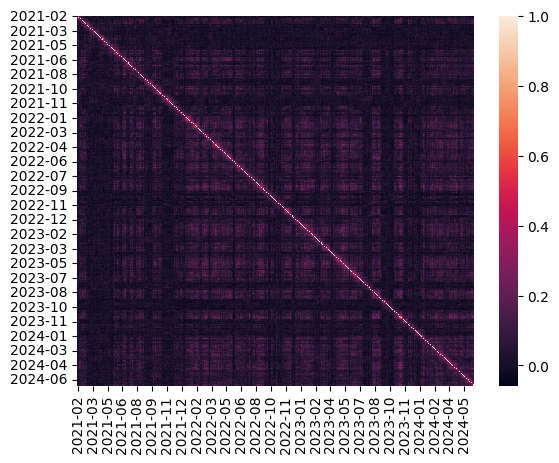

In [121]:
metric = get_cluster_rolling_metric(clusters_rolling)

rename_lambda = lambda name: name.strftime('%Y-%m')
sns.heatmap(metric.rename(index=rename_lambda, columns=rename_lambda))
plt.show()

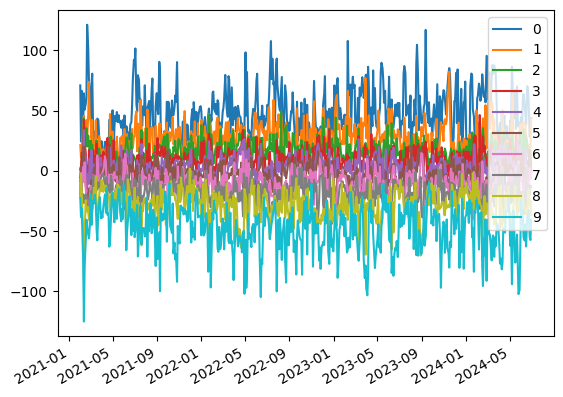

In [122]:
# computing ordered clusters
flow_graph_rolling.apply(lambda df: df.sum(1)).plot()
plt.show()

In [80]:
################################################################################################################################

In [81]:
# STRATEGY

In [44]:
"""

6. STRATEGY.PY: Create statistical arbitrage application using clustering pre-computed lead-lag matrix

"""

'\n\n6. STRATEGY.PY: Create statistical arbitrage application using clustering pre-computed lead-lag matrix\n\n'

In [123]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import norm

def sharpe_ratio_test(log_ret, value):
    '''
    Implements the sharpe ratio test from Opdyke 2007
    :param log_ret: daily log-returns
    :return: annualised sharpe ratio and p-value
    '''
    sharpe = log_ret.mean()/log_ret.std()
    sharpe_annualised = sharpe * np.sqrt(value)

    T = len(log_ret)
    std = log_ret.std()
    skew = (((log_ret - log_ret.mean()) / std) ** 3).mean()
    kurtosis = (((log_ret - log_ret.mean()) / std) ** 4).mean()

    sharpe_se = np.sqrt((1 + sharpe ** 2 / 4 * (kurtosis - 1) - sharpe * skew) / T)

    p_value = 1 - norm.cdf(sharpe/sharpe_se)

    return [sharpe_annualised.round(2), p_value]

In [124]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
from importlib import reload
import pickle
from functools import partial
import time
import numpy as np
import pandas as pd
import multiprocessing as mp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import math

log_ret_type = '' # _residuals
daily_ret = pd.read_pickle('./data/binance_real_data/daily_returns' + log_ret_type + '.pkl')
lookback = 30
update_freq = 1
correlation_method = 'mutual_information'  # 'pearson' , 'mutual_information', 'distance'
method = 'signature' # 'ccf_auc', 'ccf_at_max_lag'

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')
lead_lag_matrix = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')
clusters_rolling = pd.read_pickle('./data/binance_pickled_data/clusters_rolling_lookback_' + str(lookback) + '_update_freq_' +
                                  str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method+ '.pkl')

In [160]:
lead_lag_matrix_rolling.head(10)

2021-02-02              ROSE      ANKR       VET      NEAR  ...
2021-02-04              ROSE      ANKR       VET      NEAR  ...
2021-02-06              ROSE      ANKR       VET      NEAR  ...
2021-02-10               ROSE      ANKR       VET       NEAR...
2021-02-12              ROSE      ANKR        VET       NEAR...
2021-02-14              ROSE      ANKR       VET      NEAR  ...
2021-02-17              ROSE      ANKR       VET      NEAR  ...
2021-02-19              ROSE      ANKR       VET      NEAR  ...
2021-02-21              ROSE      ANKR        VET      NEAR ...
2021-02-24              ROSE       ANKR        VET      NEAR...
dtype: object

In [125]:
lead_lag_matrix_rolling.index = lead_lag_matrix_rolling.index + pd.DateOffset(days=1)

In [155]:
lead_lag_matrix_rolling

2021-02-02              ROSE      ANKR       VET      NEAR  ...
2021-02-04              ROSE      ANKR       VET      NEAR  ...
2021-02-06              ROSE      ANKR       VET      NEAR  ...
2021-02-10               ROSE      ANKR       VET       NEAR...
2021-02-12              ROSE      ANKR        VET       NEAR...
                                    ...                        
2023-12-22              ROSE      ANKR       VET      NEAR  ...
2023-12-24              ROSE      ANKR       VET      NEAR  ...
2023-12-27              ROSE      ANKR       VET      NEAR  ...
2023-12-29              ROSE       ANKR        VET      NEAR...
2023-12-31              ROSE       ANKR       VET      NEAR ...
Length: 456, dtype: object

In [126]:
'''1'''
start_date1 = '2021-02-01'
end_date1 = '2021-05-31'

# Loop through each date and set the values for 'BAKE' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date1, end=end_date1):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['BAKE'] = 0

###############################################################
'''2'''
start_date2 = '2021-02-01'
end_date2 = '2021-04-15'

# Loop through each date and set the values for 'ALICE' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date2, end=end_date2):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['ALICE'] = 0

###############################################################
'''3'''
start_date3 = '2021-02-01'
end_date3 = '2021-04-29'

# Loop through each date and set the values for 'CFX' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date3, end=end_date3):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['CFX'] = 0

###############################################################
'''4'''
start_date4 = '2024-06-18'
end_date4 = '2024-06-30'

# Loop through each date and set the values for 'WAVES' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date4, end=end_date4):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['WAVES'] = 0

###############################################################
'''5'''
start_date5 = '2024-06-18'
end_date5 = '2024-06-30'

# Loop through each date and set the values for 'OMG' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date5, end=end_date5):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['OMG'] = 0

###############################################################
'''6'''
start_date6 = '2021-02-01'
end_date6 = '2021-05-31'

# Loop through each date and set the values for 'SLP' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date6, end=end_date6):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['SLP'] = 0

#################################################################
'''7'''
start_date7 = '2021-02-01'
end_date7 = '2021-03-22'

# Loop through each date and set the values for 'CAKE' to 0 (as it is currently shown as #VALUE in Excel)
for date in pd.date_range(start=start_date7, end=end_date7):
    if date in lead_lag_matrix_rolling.index:
        lead_lag_matrix_rolling[date]['CAKE'] = 0

In [127]:
lead_lag_matrix_rolling

2021-02-02              ROSE      ANKR       VET      NEAR  ...
2021-02-04              ROSE      ANKR       VET      NEAR  ...
2021-02-06              ROSE      ANKR       VET      NEAR  ...
2021-02-10               ROSE      ANKR       VET       NEAR...
2021-02-12              ROSE      ANKR        VET       NEAR...
                                    ...                        
2024-06-21              ROSE      ANKR       VET      NEAR  ...
2024-06-23              ROSE      ANKR       VET      NEAR  ...
2024-06-26              ROSE      ANKR       VET      NEAR  ...
2024-06-28              ROSE      ANKR       VET      NEAR  ...
2024-06-30              ROSE      ANKR       VET      NEAR  ...
Length: 534, dtype: object

In [128]:
clusters_rolling

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
2021-02-01,6,5,5,2,5,8,7,6,5,7,...,5,7,8,8,6,7,8,5,5,5
2021-02-03,3,9,4,2,7,8,1,6,9,1,...,4,1,8,8,6,1,9,3,4,2
2021-02-05,5,9,6,2,6,9,1,1,5,1,...,6,1,9,9,2,1,9,5,2,7
2021-02-09,0,7,4,0,0,7,0,0,0,0,...,4,1,7,7,1,1,7,7,4,7
2021-02-11,1,2,5,1,2,6,2,2,1,2,...,5,0,6,6,3,0,3,6,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-20,5,2,2,2,2,2,9,2,5,8,...,2,7,1,0,3,3,3,3,3,3
2024-06-22,9,2,5,2,5,2,3,2,2,8,...,1,5,1,0,4,4,4,4,4,4
2024-06-25,8,3,3,3,3,3,9,1,2,5,...,5,6,0,0,5,0,5,5,5,5
2024-06-27,7,4,4,4,4,4,9,2,5,7,...,1,5,3,2,1,1,1,1,1,1


In [129]:
daily_ret.index = pd.to_datetime(daily_ret.index)
clusters_rolling.index = pd.to_datetime(clusters_rolling.index)

In [130]:
lead_lag_matrix_rolling.to_pickle('new_lead_lag_matrix.pkl')

In [131]:
lead_lag_matrix_rolling[1]['CAKE']

ROSE    0
ANKR    0
VET     0
NEAR    0
ETH     0
       ..
AAVE    0
DOGE    0
NEO     0
SAND    0
QTUM    0
Name: CAKE, Length: 72, dtype: int64

In [132]:
sorted(lead_lag_matrix.sum(axis=1), reverse=True)[:5]

[622.1076881500708,
 532.484526223242,
 502.8727247459092,
 495.99987529747744,
 464.96927604438616]

In [133]:
sorted(lead_lag_matrix.sum(axis=1))[:5]

[-435.5071426773821,
 -392.2601773233399,
 -365.0210069403072,
 -359.64245723036777,
 -339.90292644524317]

In [134]:
'''QUANTILE STRATEGY'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def identify_quantiles(row_sums):

    row_sums = row_sums[row_sums != -1] # Eliminate tokens with no value (row-sum = 0)

    leaders_threshold = np.percentile(row_sums, 50)
    followers_threshold = np.percentile(row_sums, 50)

    leaders = row_sums[row_sums > leaders_threshold].index
    followers = row_sums[row_sums < followers_threshold].index

    return leaders, followers

def calculate_portfolio_returns(prices, portfolio):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)
    returns = np.log(prices[portfolio]).diff().mean(axis=1)
    return returns

def trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover):
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Ensure indices are datetime
    for df in [prices, market, tbill, MACD_signal, marketcap_turnover]:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

    prices = prices.reindex(marketcap_turnover.index)
    market = market.reindex(marketcap_turnover.index)
    tbill = tbill.reindex(marketcap_turnover.index)
    MACD_signal = MACD_signal.reindex(marketcap_turnover.index)

    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in marketcap_turnover.index:
        row = marketcap_turnover.loc[date]
        leaders, followers = identify_quantiles(row)

        if len(leaders) == 0 or len(followers) == 0:
            continue

        if date in marketcap_turnover.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
               if returns_data.at[date, 'leaders'] > 0:
                    signals.at[date] = 1  # Buy followers, short leaders
               else:
                    signals.at[date] = 0
            elif returns_data.at[date, 'MACD_signal'] == -1:
               if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1  # Short followers, buy leaders
               else:
                    signals.at[date] = 0
            else:
                  signals.at[date] = 0

    returns_data['signal'] = signals
    returns_data['strategy_returns'] = (
        returns_data['signal'].shift(1) * returns_data['followers'] -
        returns_data['signal'].shift(1) * returns_data['leaders']
    )

    returns_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    returns_data.dropna(subset=['leaders', 'followers', 'strategy_returns'], inplace=True)

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0):
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1
    excess_returns = strategy_returns - daily_risk_free_rate
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()
    sharpe_ratio = mean_excess_return / std_excess_return
    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns):
    cumulative_return = (1 + strategy_returns).cumprod()
    n_years = (strategy_returns.index[-1] - strategy_returns.index[0]).days / 365.25
    annual_compounded_return = (cumulative_return.iloc[-1] ** (1/n_years)) - 1
    return annual_compounded_return * 100

In [135]:
# Create a dictionary to store the DataFrames with dates as keys
leaders_followers_dict = {}
lead_lag_matrix_rolling = lead_lag_matrix_rolling

# Iterate through each date and its corresponding lead-lag matrix
for date, lead_lag_matrix in lead_lag_matrix_rolling.items():
    # Identify leaders and followers with defined percentiles
    leaders, followers = identify_quantiles(lead_lag_matrix)

    temp_df = pd.DataFrame({
        'leaders': pd.Series(leaders),
        'followers': pd.Series(followers)
    })

    # Store this DataFrame in the dictionary with the date as the key
    leaders_followers_dict[date] = temp_df

In [136]:
print(lead_lag_matrix_rolling.index)

DatetimeIndex(['2021-02-02', '2021-02-04', '2021-02-06', '2021-02-10',
               '2021-02-12', '2021-02-14', '2021-02-17', '2021-02-19',
               '2021-02-21', '2021-02-24',
               ...
               '2024-06-09', '2024-06-12', '2024-06-14', '2024-06-16',
               '2024-06-19', '2024-06-21', '2024-06-23', '2024-06-26',
               '2024-06-28', '2024-06-30'],
              dtype='datetime64[ns]', length=534, freq=None)


In [137]:
lead_lag_matrix_rolling = lead_lag_matrix_rolling[:'2023-12-31']

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/679988289.py:64: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)


Sharpe Ratio: -0.6972861348070363
Cumulative Return: -57.00729554214373 %
Daily Volatility: 3.439642775123291 %
Daily Return: -0.12553879002450177 %
Max Drawdown: 76.71273849432147 %
Annual Compounded Return: -49.194575263955876 %
[-0.7, 0.7833403130746259]


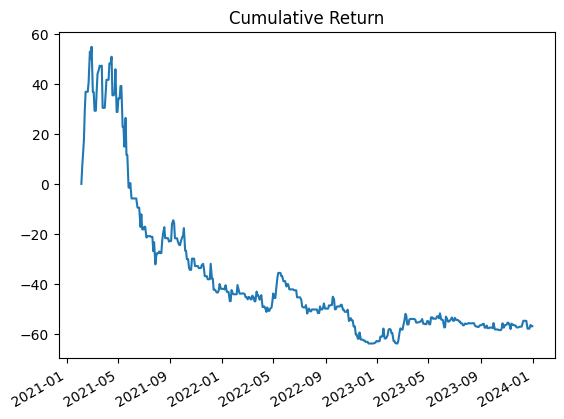

In [138]:
'''STRATEGY 1 - 50% Quantile - WITH market return considered'''

from scipy.stats.mstats import winsorize

def identify_quantiles(lead_lag_matrix):
    row_sums = lead_lag_matrix.sum(axis=1)
    row_sums = row_sums[row_sums != 0] # Eliminate tokens with no value (row-sum = 0)

    leaders_threshold = np.percentile(row_sums, 50)
    followers_threshold = np.percentile(row_sums, 50)

    leaders = row_sums[row_sums > leaders_threshold].index
    followers = row_sums[row_sums < followers_threshold].index

    return leaders, followers

def calculate_portfolio_returns(prices, portfolio, lower_percentile=1, upper_percentile=99):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)

    # Calculate log returns
    log_returns = np.log(prices[portfolio]).diff()

    # Apply winsorization to each column in the log_returns DataFrame
    winsorized_returns = log_returns.apply(lambda x: winsorize(x, limits=(lower_percentile, 1-upper_percentile)), axis=0)

    # Calculate the mean of the winsorized returns
    returns = winsorized_returns.mean(axis=1)

    return returns

def trading_strategy(prices, market, tbill, MACD_signal, lead_lag_matrix_rolling):
    # Ensure all data is numeric
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Convert index to DatetimeIndex if not already
    if not isinstance(prices.index, pd.DatetimeIndex):
        prices.index = pd.to_datetime(prices.index)
    if not isinstance(market.index, pd.DatetimeIndex):
        market.index = pd.to_datetime(market.index)
    if not isinstance(tbill.index, pd.DatetimeIndex):
        tbill.index = pd.to_datetime(tbill.index)
    if not isinstance(MACD_signal.index, pd.DatetimeIndex):
        MACD_signal.index = pd.to_datetime(MACD_signal.index)
    if not isinstance(lead_lag_matrix_rolling.index, pd.DatetimeIndex):
        lead_lag_matrix_rolling.index = pd.to_datetime(lead_lag_matrix_rolling.index)

    # Reindex prices and market to align with lead_lag_matrix_rolling index
    prices = prices.reindex(lead_lag_matrix_rolling.index)
    market = market.reindex(lead_lag_matrix_rolling.index)
    tbill = tbill.reindex(lead_lag_matrix_rolling.index)
    MACD_signal = MACD_signal.reindex(lead_lag_matrix_rolling.index)

    # Prepare DataFrame to store returns and signals
    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)  # Market returns
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal['Signal']


    signals = pd.Series(index=prices.index)

    for date in lead_lag_matrix_rolling.index:
        lead_lag_matrix = lead_lag_matrix_rolling.loc[date]

        leaders, followers = identify_quantiles(lead_lag_matrix)

        if len(leaders) == 0 or len(followers) == 0:
            continue  # Skip if no leaders or followers identified

        # Calculate returns for leaders and followers
        if date in lead_lag_matrix_rolling.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders, lower_percentile=0.01, upper_percentile=0.99).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers, lower_percentile=0.01, upper_percentile=0.99).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
                if returns_data.at[date, 'leaders'] >= 0:
                    signals.at[date] = 1 # Buy followers, short market
                else:
                    signals.at[date] = 0 # Do nothing
            elif returns_data.at[date, 'MACD_signal'] == -1:
                if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1 # Short followers, buy market
                else:
                    signals.at[date] = 0 # Do nothing
            else:
                  signals.at[date] = 0 # Do nothing

    # Calculate strategy returns intraday
    returns_data['signal'] = signals.shift(1)
    returns_data['strategy_returns'] = returns_data['signal'] * (
        returns_data['followers'] - returns_data['market']
    )
     # Remove -inf, inf, and NaN values from leaders, followers, and strategy_returns
    returns_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    returns_data.dropna(subset=['leaders', 'followers', 'strategy_returns'], inplace=True)

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0):
    # Assume the risk-free rate is annual, convert it to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1

    # Calculate excess returns
    excess_returns = strategy_returns - daily_risk_free_rate

    # Calculate average excess return and standard deviation of excess returns
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()

    # Calculate Sharpe ratio
    sharpe_ratio = mean_excess_return / std_excess_return

    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100  # Basis points

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns, value):
    cumulative_return = (1 + strategy_returns).cumprod().iloc[-1]
    n_weeks = len(strategy_returns)  # Number of weeks
    n_years = n_weeks / value  # Convert weeks to years

    # Annualize the compounded return
    annual_compounded_return = (cumulative_return ** (1/n_years)) - 1
    return annual_compounded_return * 100

prices = close_price
tbill = pd.read_csv('../../Data/tbill_data.csv', index_col='date')
market = pd.read_csv('../../Data/market_data_BGCI_Index.csv', index_col='date')
MACD = pd.read_csv('../../Data/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD'], axis=1)

lead_lag_rolling_matrix = lead_lag_matrix_rolling
strategy_results = trading_strategy(prices, market, tbill, MACD_signal, lead_lag_rolling_matrix)
strategy_returns = strategy_results['strategy_returns'].dropna()
strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)
value = 365

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_returns)
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(value) # CHANGE THIS ACCORDING TO THE LEVEL OF DATA
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns, value)

print("Cumulative Return:", cumulative_return.iloc[-1], '%')  # Print the final cumulative return value
print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

print(sharpe_ratio_test(strategy_returns, value))
# Plot cumulative return
cumulative_return.plot(title='Cumulative Return')
plt.show()

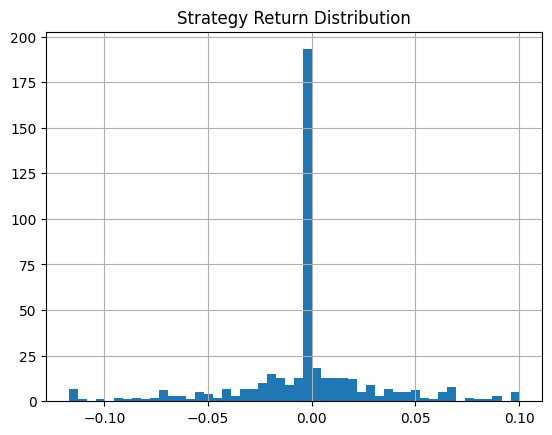

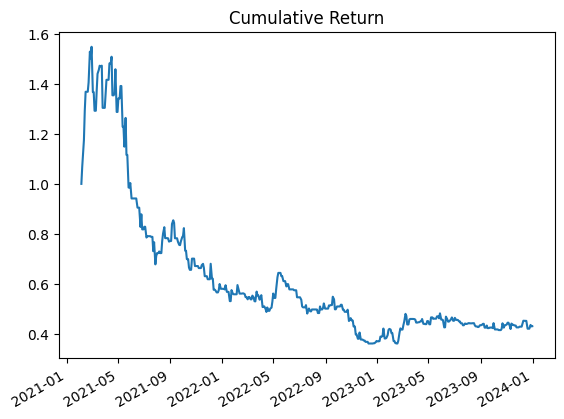

In [139]:
strategy_returns.hist(bins=50)
plt.title('Strategy Return Distribution')
plt.show()

(1 + strategy_returns).cumprod().plot(title='Cumulative Return')
plt.show()


In [140]:
print("Signal counts:\n", MACD_signal['Signal'].value_counts())

Signal counts:
  1    582
-1    510
 0      3
Name: Signal, dtype: int64


count    455.000000
mean      -0.003585
std        0.025651
min       -0.139254
25%       -0.013745
50%        0.000138
75%        0.010574
max        0.078535
dtype: float64


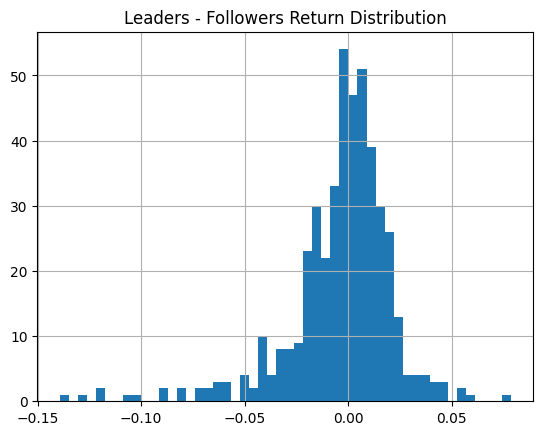

In [141]:
diff = strategy_results['leaders'] - strategy_results['followers']
print(diff.describe())
diff.hist(bins=50)
plt.title("Leaders - Followers Return Distribution")
plt.show()


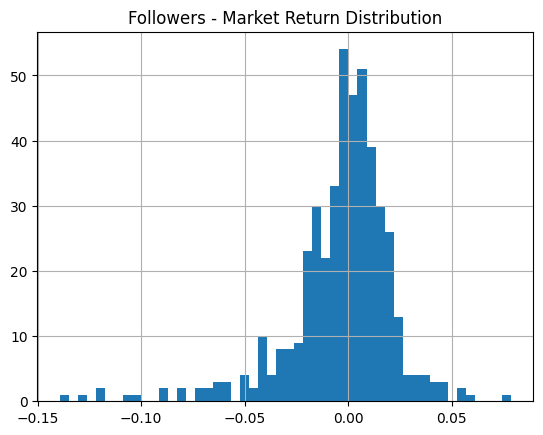

In [142]:
diff.hist(bins=50)
plt.title("Followers - Market Return Distribution")
plt.show()

In [143]:
def winsorize_returns(returns, lower_percentile, upper_percentile): # Use for winsorizing the strategy returns later on
    lower_bound = np.percentile(returns, lower_percentile)
    upper_bound = np.percentile(returns, upper_percentile)
    returns_clipped = np.clip(returns, lower_bound, upper_bound)
    return pd.Series(returns_clipped, index=returns.index)

In [144]:
file_path = './data/strategy1_results.xlsx'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_excel(file_path, index=True)
print(f"Data saved to {file_path}")

Data saved to ./data/strategy1_results.xlsx


In [150]:
# Permutation test for Sharpe ratio

def permutation_test_sharpe(prices, lead_lag_matrix_rolling, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, lead_lag_matrix_rolling)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = lead_lag_matrix_rolling.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, permuted_lead_lag_matrix_rolling)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('../../Data/market_data_BGCI_Index.csv', index_col='date')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/679988289.py:64: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/679988289.py:64: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/679988289.py:64: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/679988289.py:64: FutureWarning: The default dtype for empty Series will be 'obje

Observed Sharpe Ratio: -0.0318477621283964
P-value: 0.000999000999000999


In [151]:
# Plot Historical Market Prices with Buy/Sell Signals

signals = strategy_results[['date', 'signal']]
signals['date'] = pd.to_datetime(signals['date'])

market = pd.read_csv('market_data.csv',parse_dates=['date'], index_col='date')
check_data = pd.merge(market.reset_index(), signals, on='date')

# Extract the data
dates = check_data['date']
prices = check_data['market']
signals = check_data['signal']

# Create a plot
plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

KeyError: "['date'] not in index"

In [ ]:
############################################################################################################################################################################################

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/753714307.py:61: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)


Sharpe Ratio: 1.3332526626708117
Cumulative Return: -100.00000000002105 %
Daily Volatility: 41.26989829628164 %
Daily Return: 2.880046011526936 %
Max Drawdown: 120.98187721810037 %
Annual Compounded Return: nan %


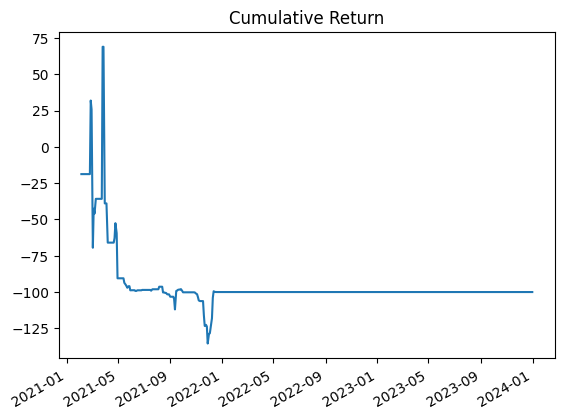

In [111]:
'''STRATEGY 2 - 50% Quantile - WITHOUT market return considered'''

def identify_quantiles(lead_lag_matrix):
    row_sums = lead_lag_matrix.sum(axis=1)
    row_sums = row_sums[row_sums != 0] # Eliminate tokens with no value (row-sum = 0)

    leaders_threshold = np.percentile(row_sums, 50)
    followers_threshold = np.percentile(row_sums, 50)

    leaders = row_sums[row_sums > leaders_threshold].index
    followers = row_sums[row_sums < followers_threshold].index

    return leaders, followers

def calculate_portfolio_returns(daily_returns_row, portfolio, lower_percentile=0.01, upper_percentile=0.01):
    if len(portfolio) == 0:
        return np.nan  # 只有一行，就返回一个值

    selected_returns = daily_returns_row[portfolio]

    # Winsorize
    lower = lower_percentile
    upper = upper_percentile
    winsorized = winsorize(selected_returns, limits=(lower, upper))

    return np.nanmean(winsorized)  # 返回的是一个数，不是 Series


def trading_strategy(prices, daily_ret, market, tbill, MACD_signal, lead_lag_matrix_rolling):
    # Ensure all data is numeric
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Convert index to DatetimeIndex if not already
    if not isinstance(prices.index, pd.DatetimeIndex):
        prices.index = pd.to_datetime(prices.index)
    if not isinstance(market.index, pd.DatetimeIndex):
        market.index = pd.to_datetime(market.index)
    if not isinstance(tbill.index, pd.DatetimeIndex):
        tbill.index = pd.to_datetime(tbill.index)
    if not isinstance(MACD_signal.index, pd.DatetimeIndex):
        MACD_signal.index = pd.to_datetime(MACD_signal.index)
    if not isinstance(lead_lag_matrix_rolling.index, pd.DatetimeIndex):
        lead_lag_matrix_rolling.index = pd.to_datetime(lead_lag_matrix_rolling.index)

    # Reindex prices and market to align with lead_lag_matrix_rolling index
    prices = prices.reindex(lead_lag_matrix_rolling.index)
    daily_ret = daily_ret.reindex(lead_lag_matrix_rolling.index)
    market = market.reindex(lead_lag_matrix_rolling.index)
    tbill = tbill.reindex(lead_lag_matrix_rolling.index)
    MACD_signal = MACD_signal.reindex(lead_lag_matrix_rolling.index)

    # Prepare DataFrame to store returns and signals
    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)  # Market returns
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in lead_lag_matrix_rolling.index:
        lead_lag_matrix = lead_lag_matrix_rolling.loc[date]

        leaders, followers = identify_quantiles(lead_lag_matrix)

        if len(leaders) == 0 or len(followers) == 0:
            continue  # Skip if no leaders or followers identified

        # Calculate returns for leaders and followers
        returns_data.at[date, 'leaders'] = calculate_portfolio_returns(daily_ret.loc[date], leaders, lower_percentile=0.01, upper_percentile=0.99)
        returns_data.at[date, 'followers'] = calculate_portfolio_returns(daily_ret.loc[date], followers, lower_percentile=0.01, upper_percentile=0.99)

        if returns_data.at[date, 'MACD_signal'] == 1:
            if returns_data.at[date, 'leaders'] >= 0:
                signals.at[date] = 1 # Buy followers, short leaders
            else:
                signals.at[date] = 0 # Do nothing
        elif returns_data.at[date, 'MACD_signal'] == -1:
            if returns_data.at[date, 'leaders'] < 0:
                signals.at[date] = -1 # Short followers, buy leaders
            else:
                signals.at[date] = 0 # Do nothing
        else:
            signals.at[date] = 0 # Do nothing

    # Calculate strategy returns intraday
    returns_data['signal'] = signals.shift(1)
    returns_data['strategy_returns'] = returns_data['signal'] * (
        returns_data['followers'] - returns_data['leaders']
    )

    # Remove -inf, inf, and NaN values from leaders, followers, and strategy_returns
    returns_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    returns_data.dropna(subset=['leaders', 'followers', 'strategy_returns'], inplace=True)

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0):
    # Assume the risk-free rate is annual, convert it to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1

    # Calculate excess returns
    excess_returns = strategy_returns - daily_risk_free_rate

    # Calculate average excess return and standard deviation of excess returns
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()

    # Calculate Sharpe ratio
    sharpe_ratio = mean_excess_return / std_excess_return

    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100  # Basis points

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown
    
def calculate_annual_compounded_return(strategy_returns, value):
    cumulative_return = (1 + strategy_returns).cumprod().iloc[-1]
    
    if cumulative_return <= 0:
        return np.nan  # 防止负值导致 nan 或 complex

    n_weeks = len(strategy_returns)
    n_years = n_weeks / value

    return ((cumulative_return) ** (1/n_years) - 1) * 100

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return


# Example usage with hypothetical `prices` and `lead_lag_rolling_matrix` DataFrames
prices = close_price
tbill = pd.read_csv('../../Data/tbill_data.csv', index_col='date')
market = pd.read_csv('../../Data/market_data_BGCI_Index.csv', index_col='date')
MACD = pd.read_csv('../../Data/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'],axis = 1)

lead_lag_rolling_matrix = lead_lag_matrix_rolling

strategy_results = trading_strategy(prices, daily_ret, market, tbill, MACD_signal, lead_lag_rolling_matrix)

strategy_returns = strategy_results['strategy_returns'].dropna()
strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)
value = 365

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_returns)
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(value) # CHANGE THIS ACCORDING TO THE LEVEL OF DATA
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns, value)

print("Cumulative Return:", cumulative_return.iloc[-1], '%')  # Print the final cumulative return value
print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

# Plot cumulative return
cumulative_return.plot(title='Cumulative Return')
plt.show()

In [106]:
file_path = './data/strategy2_results.xlsx'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_excel(file_path, index=True)
print(f"Data saved to {file_path}")

Data saved to ./data/strategy2_results.xlsx


In [109]:
# Permutation test for Sharpe ratio

def permutation_test_sharpe(prices, lead_lag_matrix_rolling, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, lead_lag_matrix_rolling)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = lead_lag_matrix_rolling.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, permuted_lead_lag_matrix_rolling)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('../../Data/market_data_BGCI_Index.csv', index_col='date')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

TypeError: trading_strategy() missing 3 required positional arguments: 'tbill', 'MACD_signal', and 'lead_lag_matrix_rolling'

In [ ]:
# Plot Historical Market Prices with Buy/Sell Signals

signals = strategy_results[['date', 'signal']]
signals['date'] = pd.to_datetime(signals['date'])

market = pd.read_csv('market_data.csv',parse_dates=['date'], index_col='date')
check_data = pd.merge(market.reset_index(), signals, on='date')

# Extract the data
dates = check_data['date']
prices = check_data['market']
signals = check_data['signal']

# Create a plot
plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [ ]:
############################################################################################################################################################################################

In [110]:
'''NEW STRATEGY 3 - Hermitian clustering - WITH market return'''

import pandas as pd
import numpy as np

def identify_clusters(cluster_rolling, date):
    """
    Identify leaders and followers based on clustering information.
    """
    clusters = cluster_rolling.loc[date]
    leaders = clusters[(clusters == 0) | (clusters == 1) ].index
    followers = clusters[(clusters == 5) | (clusters == 4) ].index
    ignores = clusters[(clusters == -1)]

    return leaders, followers, ignores

def calculate_portfolio_returns(prices, portfolio, lower_percentile=1, upper_percentile=0.99):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)

    # Calculate log returns
    log_returns = np.log(prices[portfolio]).diff()

    # Apply winsorization to each column in the log_returns DataFrame
    winsorized_returns = log_returns.apply(lambda x: winsorize(x, limits=(lower_percentile, 1-upper_percentile)), axis=0)

    # Calculate the mean of the winsorized returns
    returns = winsorized_returns.mean(axis=1)

    return returns

def trading_strategy(prices, market, tbill, MACD_signal, lead_lag_matrix_rolling, clusters_rolling):
    # Ensure all data is numeric
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Convert index to DatetimeIndex if not already
    if not isinstance(prices.index, pd.DatetimeIndex):
        prices.index = pd.to_datetime(prices.index)
    if not isinstance(market.index, pd.DatetimeIndex):
        market.index = pd.to_datetime(market.index)
    if not isinstance(tbill.index, pd.DatetimeIndex):
        tbill.index = pd.to_datetime(tbill.index)
    if not isinstance(MACD_signal.index, pd.DatetimeIndex):
        MACD_signal.index = pd.to_datetime(MACD_signal.index)
    if not isinstance(lead_lag_matrix_rolling.index, pd.DatetimeIndex):
        lead_lag_matrix_rolling.index = pd.to_datetime(lead_lag_matrix_rolling.index)
    if not isinstance(clusters_rolling.index, pd.DatetimeIndex):
        clusters_rolling.index = pd.to_datetime(clusters_rolling.index)

    # Reindex prices and market to align with lead_lag_matrix_rolling index
    prices = prices.reindex(lead_lag_matrix_rolling.index)
    market = market.reindex(lead_lag_matrix_rolling.index)
    tbill = tbill.reindex(lead_lag_matrix_rolling.index)
    MACD_signal = MACD_signal.reindex(lead_lag_matrix_rolling.index)
    clusters_rolling = clusters_rolling.reindex(lead_lag_matrix_rolling.index)

    # Prepare DataFrame to store returns and signals
    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)  # Market returns
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in lead_lag_matrix_rolling.index:
        # Identify leaders and followers based on clustering
        leaders, followers, ignores = identify_clusters(clusters_rolling, date)

        if len(leaders) == 0 or len(followers) == 0:
            continue  # Skip if no leaders or followers identified

        # Calculate returns for leaders and followers
        if date in lead_lag_matrix_rolling.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders, lower_percentile=1, upper_percentile=99).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers, lower_percentile=1, upper_percentile=99).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
                if returns_data.at[date, 'leaders'] > 0:
                    signals.at[date] = 1  # Buy followers, short market
                else:
                    signals.at[date] = 0
            elif returns_data.at[date, 'MACD_signal'] == -1:
                if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1  # Short followers, buy market
                else:
                    signals.at[date] = 0
            else:
                signals.at[date] = 0

    # Ensure that 'followers' and 'leaders' columns are created
    if 'followers' not in returns_data.columns:
        returns_data['followers'] = np.nan
    if 'leaders' not in returns_data.columns:
        returns_data['leaders'] = np.nan

    # Calculate strategy returns
    returns_data['signal'] = signals.shift(1)
    returns_data['strategy_returns'] = (
        returns_data['signal'] * returns_data['followers'] -
        returns_data['signal'] * returns_data['market']
    )

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0.00):
    # Assume the risk-free rate is annual, convert it to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1

    # Calculate excess returns
    excess_returns = strategy_returns - daily_risk_free_rate

    # Calculate average excess return and standard deviation of excess returns
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()

    # Calculate Sharpe ratio
    sharpe_ratio = mean_excess_return / std_excess_return

    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100  # Basis points

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns, value):
    cumulative_return = (1 + strategy_returns).cumprod().iloc[-1]
    n_weeks = len(strategy_returns)  # Number of weeks
    n_years = n_weeks / value  # Convert weeks to years

    # Annualize the compounded return
    annual_compounded_return = (cumulative_return ** (1/n_years)) - 1
    return annual_compounded_return * 100

# Example usage with hypothetical `prices` and `lead_lag_rolling_matrix` DataFrames
prices = close_price
tbill = tbill
market = market
MACD = MACD
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)


lead_lag_rolling_matrix = lead_lag_matrix_rolling
clusters_rolling = clusters_rolling

strategy_results = trading_strategy(prices, market, tbill, MACD_signal, lead_lag_rolling_matrix, clusters_rolling)
strategy_results = strategy_results.dropna()

strategy_returns = strategy_results['strategy_returns']
strategy_returns.replace([np.inf, -np.inf], 0, inplace=True)
strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)
value = 365

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_returns.dropna())
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(value) # CHANGE THIS ACCORDING TO THE LEVEL OF DATA
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns, value)

print("Cumulative Return:", cumulative_return.iloc[-1], '%')  # Print the final cumulative return value
print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

print(sharpe_ratio_test(strategy_returns, value))

# Plot cumulative return
cumulative_return.plot(title='Cumulative Return')
plt.show()

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/1300104175.py:66: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)


IndexError: cannot do a non-empty take from an empty axes.

In [ ]:
file_path = './data/strategy3_results.xlsx'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_excel(file_path, index=True)
print(f"Data saved to {file_path}")

In [ ]:
# Permutation test for Sharpe ratio

def permutation_test_sharpe(prices, lead_lag_matrix_rolling, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, lead_lag_matrix_rolling)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = lead_lag_matrix_rolling.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, permuted_lead_lag_matrix_rolling)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('market_data.csv', index_col='ticker')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

In [ ]:
# Plot Historical Market Prices with Buy/Sell Signals

signals = strategy_results[['date', 'signal']]
signals['date'] = pd.to_datetime(signals['date'])

market = pd.read_csv('market_data.csv',parse_dates=['date'], index_col='date')
check_data = pd.merge(market.reset_index(), signals, on='date')

# Extract the data
dates = check_data['date']
prices = check_data['market']
signals = check_data['signal']

# Create a plot
plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [ ]:
###################################################################################################################################################################################################

In [72]:
'''NEW STRATEGY 4 - Hermitian clustering - WITHOUT market return'''

import pandas as pd
import numpy as np

def identify_clusters(cluster_rolling, date):
    """
    Identify leaders and followers based on clustering information.
    """
    clusters = cluster_rolling.loc[date]
    leaders = clusters[(clusters == 0) | (clusters == 1) ].index
    followers = clusters[(clusters == 5) | (clusters == 4) ].index
    ignores = clusters[(clusters == -1)]

    return leaders, followers, ignores

def calculate_portfolio_returns(prices, portfolio, lower_percentile=1, upper_percentile=99):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)

    # Calculate log returns
    log_returns = np.log(prices[portfolio]).diff()

    # Apply winsorization to each column in the log_returns DataFrame
    winsorized_returns = log_returns.apply(lambda x: winsorize(x, limits=(lower_percentile, 1-upper_percentile)), axis=0)

    # Calculate the mean of the winsorized returns
    returns = winsorized_returns.mean(axis=1)

    return returns

def trading_strategy(prices, market, tbill, MACD_signal, lead_lag_matrix_rolling, clusters_rolling):
    # Ensure all data is numeric
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Convert index to DatetimeIndex if not already
    if not isinstance(prices.index, pd.DatetimeIndex):
        prices.index = pd.to_datetime(prices.index)
    if not isinstance(market.index, pd.DatetimeIndex):
        market.index = pd.to_datetime(market.index)
    if not isinstance(tbill.index, pd.DatetimeIndex):
        tbill.index = pd.to_datetime(tbill.index)
    if not isinstance(MACD_signal.index, pd.DatetimeIndex):
        MACD_signal.index = pd.to_datetime(MACD_signal.index)
    if not isinstance(lead_lag_matrix_rolling.index, pd.DatetimeIndex):
        lead_lag_matrix_rolling.index = pd.to_datetime(lead_lag_matrix_rolling.index)
    if not isinstance(clusters_rolling.index, pd.DatetimeIndex):
        clusters_rolling.index = pd.to_datetime(clusters_rolling.index)

    # Reindex prices and market to align with lead_lag_matrix_rolling index
    prices = prices.reindex(lead_lag_matrix_rolling.index)
    market = market.reindex(lead_lag_matrix_rolling.index)
    tbill = tbill.reindex(lead_lag_matrix_rolling.index)
    MACD_signal = MACD_signal.reindex(lead_lag_matrix_rolling.index)
    clusters_rolling = clusters_rolling.reindex(lead_lag_matrix_rolling.index)

    # Prepare DataFrame to store returns and signals
    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)  # Market returns
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in lead_lag_matrix_rolling.index:
        # Identify leaders and followers based on clustering
        leaders, followers, ignores = identify_clusters(clusters_rolling, date)
        
        if len(leaders) == 0 or len(followers) == 0:
            print(f"{date.date()} | leaders: {len(leaders)}, followers: {len(followers)}")
            continue  # Skip if no leaders or followers identified

        # Calculate returns for leaders and followers
        if date in lead_lag_matrix_rolling.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders, lower_percentile=1, upper_percentile=99).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers, lower_percentile=1, upper_percentile=99).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
                if returns_data.at[date, 'leaders'] > 0:
                    signals.at[date] = 1  # Buy followers, short leaders
                else:
                    signals.at[date] = 0 # Do nothing
            elif returns_data.at[date, 'MACD_signal'] == -1:
                if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1  # Short followers, buy leaders
                else:
                    signals.at[date] = 0 # Do nothing
            else:
                signals.at[date] = 0 # Do nothing

    # Ensure that 'followers' and 'leaders' columns are created
    if 'followers' not in returns_data.columns:
        returns_data['followers'] = np.nan
    if 'leaders' not in returns_data.columns:
        returns_data['leaders'] = np.nan

    # Calculate strategy returns
    returns_data['signal'] = signals.shift(1)
    returns_data['strategy_returns'] = (
        returns_data['signal'] * returns_data['followers'] -
        returns_data['signal'] * returns_data['leaders']
    )

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0.00):
    # Assume the risk-free rate is annual, convert it to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1

    # Calculate excess returns
    excess_returns = strategy_returns - daily_risk_free_rate

    # Calculate average excess return and standard deviation of excess returns
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()

    # Calculate Sharpe ratio
    sharpe_ratio = mean_excess_return / std_excess_return

    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100  # Basis points

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns, value):
    cumulative_return = (1 + strategy_returns).cumprod().iloc[-1]
    n_weeks = len(strategy_returns)  # Number of weeks
    n_years = n_weeks / value  # Convert weeks to years

    # Annualize the compounded return
    annual_compounded_return = (cumulative_return ** (1/n_years)) - 1
    return annual_compounded_return * 100

# Example usage with hypothetical `prices` and `lead_lag_rolling_matrix` DataFrames
prices = close_price
tbill = tbill
market = market
MACD = MACD
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)


lead_lag_rolling_matrix = lead_lag_matrix_rolling
clusters_rolling = clusters_rolling

strategy_results = trading_strategy(prices, market, tbill, MACD_signal, lead_lag_rolling_matrix, clusters_rolling)
strategy_results = strategy_results.dropna()

strategy_returns = strategy_results['strategy_returns']
strategy_returns.replace([np.inf, -np.inf], 0, inplace=True)

if not strategy_returns.empty:
    strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)
else:
    print("Warning: strategy_returns is empty after dropna().")


strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)
value = 365

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_returns.dropna())
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(value) # CHANGE THIS ACCORDING TO THE LEVEL OF DATA
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns, value)

print("Cumulative Return:", cumulative_return.iloc[-1], '%')  # Print the final cumulative return value
print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

print(sharpe_ratio_test(strategy_returns, value))

# Plot cumulative return
cumulative_return.plot(title='Cumulative Return')
plt.show()

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_69873/960110647.py:66: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  signals = pd.Series(index=prices.index)


2021-02-02 | leaders: 0, followers: 0
2021-02-04 | leaders: 0, followers: 0
2021-02-06 | leaders: 0, followers: 0
2021-02-10 | leaders: 0, followers: 0
2021-02-12 | leaders: 0, followers: 0
2021-02-14 | leaders: 0, followers: 0
2021-02-17 | leaders: 0, followers: 0
2021-02-19 | leaders: 0, followers: 0
2021-02-21 | leaders: 0, followers: 0
2021-02-24 | leaders: 0, followers: 0
2021-02-26 | leaders: 0, followers: 0
2021-02-28 | leaders: 0, followers: 0
2021-03-03 | leaders: 0, followers: 0
2021-03-05 | leaders: 0, followers: 0
2021-03-07 | leaders: 0, followers: 0
2021-03-10 | leaders: 0, followers: 0
2021-03-12 | leaders: 0, followers: 0
2021-03-14 | leaders: 0, followers: 0
2021-03-17 | leaders: 0, followers: 0
2021-03-19 | leaders: 0, followers: 0
2021-03-21 | leaders: 0, followers: 0
2021-03-24 | leaders: 0, followers: 0
2021-03-26 | leaders: 0, followers: 0
2021-03-28 | leaders: 0, followers: 0
2021-03-31 | leaders: 0, followers: 0
2021-04-02 | leaders: 0, followers: 0
2021-04-04 |

IndexError: cannot do a non-empty take from an empty axes.

In [78]:
clusters_rolling

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
2021-02-01,4,4,4,4,4,2,3,5,4,3,...,4,3,2,2,5,3,5,1,4,1
2021-02-03,3,5,3,0,1,4,1,1,5,0,...,3,1,4,4,0,1,5,2,3,2
2021-02-05,2,5,2,2,2,3,1,1,2,1,...,2,1,5,3,2,1,3,4,2,4
2021-02-09,0,4,4,0,2,3,2,2,0,0,...,1,1,3,4,1,1,1,4,1,4
2021-02-11,2,1,3,2,1,4,1,2,2,2,...,3,0,4,4,0,0,0,3,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-20,4,1,1,1,3,1,5,1,1,4,...,1,4,3,0,2,3,2,2,2,2
2024-06-22,4,0,3,0,3,0,1,0,0,4,...,3,3,3,4,2,2,2,2,2,2
2024-06-25,5,2,2,2,0,2,5,2,2,3,...,0,2,0,0,3,0,3,3,3,3
2024-06-27,3,3,3,3,3,3,5,1,1,3,...,2,3,0,3,2,3,2,2,2,2


In [77]:
identify_clusters(clusters_rolling, '2021-02-02')

KeyError: '2021-02-02'

In [ ]:
file_path = './data/strategy4_results.xlsx'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_excel(file_path, index=True)
print(f"Data saved to {file_path}")

In [ ]:
# Permutation test for Sharpe ratio

def permutation_test_sharpe(prices, lead_lag_matrix_rolling, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, lead_lag_matrix_rolling)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = lead_lag_matrix_rolling.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, permuted_lead_lag_matrix_rolling)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('market_data.csv', index_col='ticker')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

In [ ]:
# Plot Historical Market Prices with Buy/Sell Signals

signals = strategy_results[['date', 'signal']]
signals['date'] = pd.to_datetime(signals['date'])

market = pd.read_csv('market_data.csv',parse_dates=['date'], index_col='date')
check_data = pd.merge(market.reset_index(), signals, on='date')

# Extract the data
dates = check_data['date']
prices = check_data['market']
signals = check_data['signal']

# Create a plot
plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

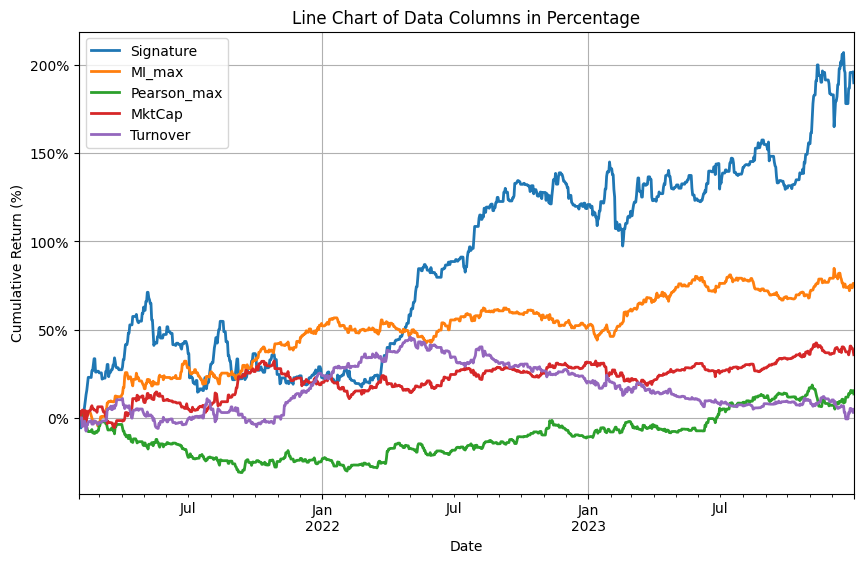

In [ ]:
# PLOT THE CUMULATIVE RETURN OF ALL THE STRATEGIES

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df = pd.read_excel('/content/Clustered_cum_returns.xlsx')

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

def to_percent(y, position):
    return f'{y * 100:.0f}%'

df.plot(figsize=(10, 6), linewidth=2)

# Customize the plot
plt.title('Line Chart of Data Columns in Percentage')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(title='', loc='best')
plt.grid(True)

plt.gca().yaxis.set_major_formatter(FuncFormatter(to_percent))

plt.show()